In [ ]:
import glob
import random
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

In [3]:
# Read in SDSS data
from sdss_data.sdss_loader import load_sdss_csv
df = load_sdss_csv("sdss_data/fields/sdss_target.csv")

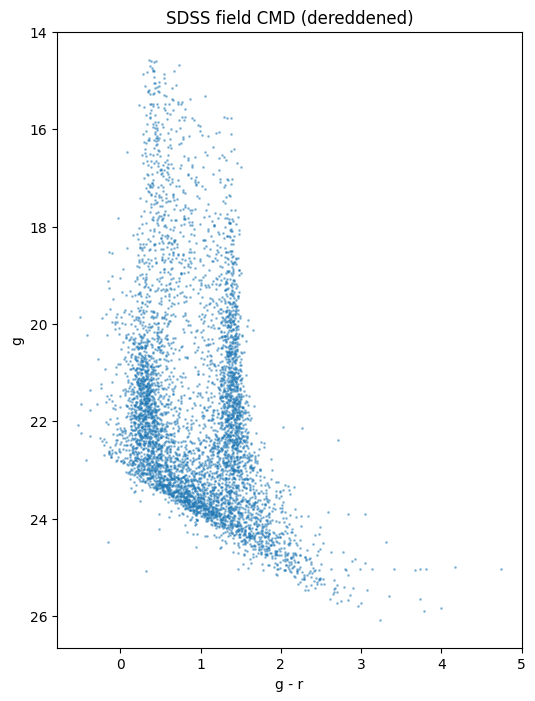

In [4]:
# Plot SDSS data on CMD without reddening as a sanity check
import matplotlib.pyplot as plt
plt.figure(figsize=(6,8))
plt.scatter(df["g_r"], df["g0"], s=1, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("g - r")
plt.ylabel("g")
plt.title("SDSS field CMD (dereddened)")
plt.show()

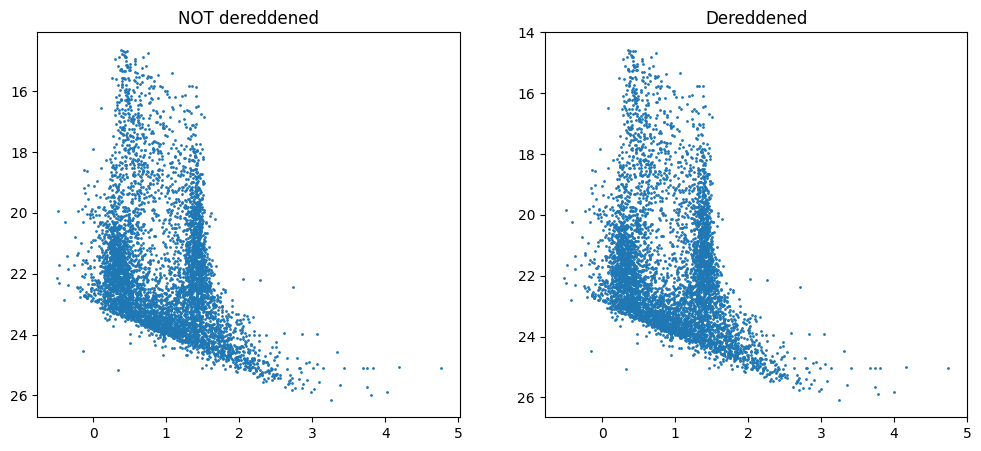

In [5]:
# Plot dereddened vs reddened CMD side by side
plt.figure(figsize=(12,5))

# reddened
plt.subplot(1,2,1)
plt.scatter(df["psfMag_g"]-df["psfMag_r"], df["psfMag_g"], s=1)
plt.gca().invert_yaxis()
plt.title("NOT dereddened")

# dereddened
plt.subplot(1,2,2)
plt.scatter(df["g_r"], df["g0"], s=1)
plt.gca().invert_yaxis()
plt.title("Dereddened")

plt.show()

In [6]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

In [7]:
# Read in Dartmouth isochrone files
from isochrones.dartmouth_iso import load_isochrones, read_dartmouth_iso
isos = load_isochrones("isochrones")
iso5 = isos["5gyr"]
iso13 = isos["13gyr"]

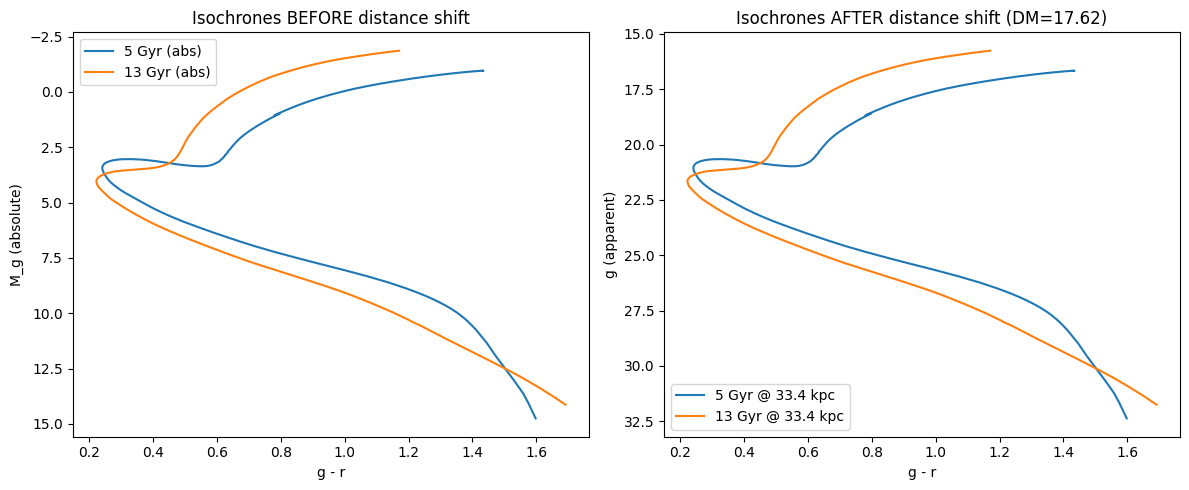

Distance modulus used: DM = 17.6187 mag for d = 33.4 kpc


In [8]:

# --- Distance modulus for d = 33.4 kpc ---
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)   # ~17.62

def iso_before_after(iso, DM):
    """Return (color_abs, Mg_abs, color_app, g_app) for one isochrone."""
    df_iso = iso.df.copy()

    # BEFORE: absolute magnitudes (intrinsic)
    color_abs = df_iso["sdss_g"] - df_iso["sdss_r"]
    Mg_abs = df_iso["sdss_g"]

    # AFTER: shifted to apparent magnitudes at the Sgr distance
    g_app = df_iso["sdss_g"] + DM
    r_app = df_iso["sdss_r"] + DM
    color_app = g_app - r_app

    return color_abs, Mg_abs, color_app, g_app


c5_abs, g5_abs, c5_app, g5_app = iso_before_after(iso5, DM)
c13_abs, g13_abs, c13_app, g13_app = iso_before_after(iso13, DM)

# --- Plot BEFORE/AFTER for distance correction ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# BEFORE (absolute mags)
ax[0].plot(c5_abs, g5_abs, lw=1.5, label="5 Gyr (abs)")
ax[0].plot(c13_abs, g13_abs, lw=1.5, label="13 Gyr (abs)")
ax[0].invert_yaxis()
ax[0].set_xlabel("g - r")
ax[0].set_ylabel("M_g (absolute)")
ax[0].set_title("Isochrones BEFORE distance shift")
ax[0].legend()

# AFTER (apparent mags at 33.4 kpc)
ax[1].plot(c5_app, g5_app, lw=1.5, label="5 Gyr @ 33.4 kpc")
ax[1].plot(c13_app, g13_app, lw=1.5, label="13 Gyr @ 33.4 kpc")
ax[1].invert_yaxis()
ax[1].set_xlabel("g - r")
ax[1].set_ylabel("g (apparent)")
ax[1].set_title(f"Isochrones AFTER distance shift (DM={DM:.2f})")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Distance modulus used: DM = {DM:.4f} mag for d = {d_pc/1000:.1f} kpc")

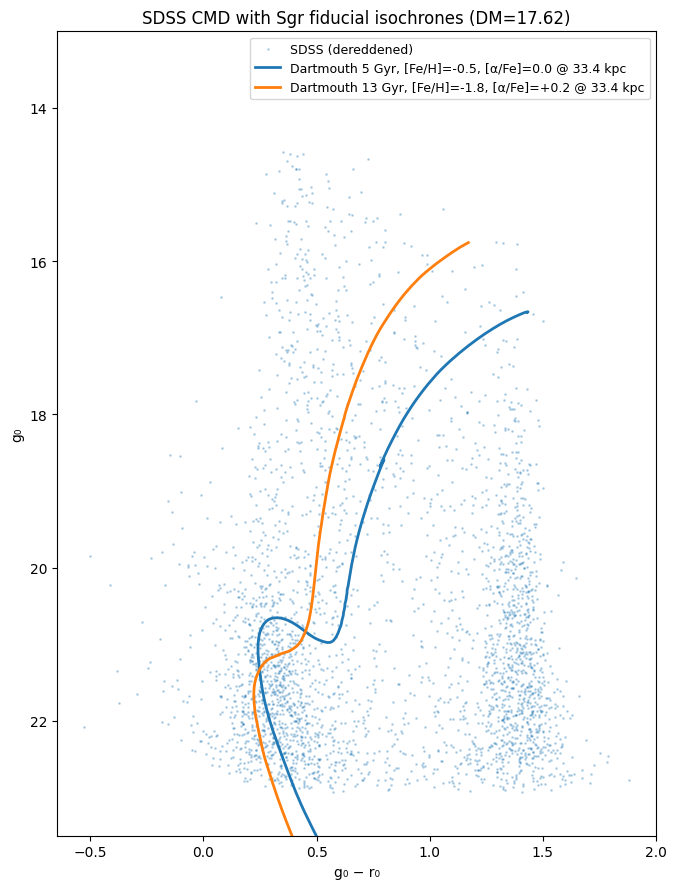

Overlay used DM = 17.6187 mag; SDSS plotted points = 3206 / 5448 (after quality cut)


In [9]:
# --- Overlay dereddened SDSS CMD with distance-shifted Dartmouth isochrones ---
# Distance modulus for Sgr field (33.4 kpc)
d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)

# light quality cut to keep the CMD readable
mask = (
    (df["psfMagErr_g"] < 0.15) &
    (df["psfMagErr_r"] < 0.15) &
    (df["g0"] < 23.5) &
    (df["r0"] < 23.5)
)
d = df[mask].copy()

def shifted_iso(iso, DM):
    """Return (color, mag) arrays for plotting an isochrone shifted to apparent mags."""
    iso_df = iso.df
    g_app = iso_df["sdss_g"] + DM
    r_app = iso_df["sdss_r"] + DM
    color = g_app - r_app
    return color.to_numpy(), g_app.to_numpy()

c5, g5 = shifted_iso(iso5, DM)
c13, g13 = shifted_iso(iso13, DM)

plt.figure(figsize=(7, 9))

# SDSS (dereddened)
plt.scatter(d["g_r"], d["g0"], s=1, alpha=0.25, label="SDSS (dereddened)")

# Isochrones (shifted to 33.4 kpc; no extinction added)
plt.plot(c5, g5, lw=2, label="Dartmouth 5 Gyr, [Fe/H]=-0.5, [α/Fe]=0.0 @ 33.4 kpc")
plt.plot(c13, g13, lw=2, label="Dartmouth 13 Gyr, [Fe/H]=-1.8, [α/Fe]=+0.2 @ 33.4 kpc")

plt.gca().invert_yaxis()
plt.xlabel("g₀ − r₀")
plt.ylabel("g₀")
plt.title(f"SDSS CMD with Sgr fiducial isochrones (DM={DM:.2f})")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()

plt.ylim(23.5, 13)

plt.show()

print(f"Overlay used DM = {DM:.4f} mag; SDSS plotted points = {len(d)} / {len(df)} (after quality cut)")

Total stars after quality cut: 3206
Candidates (5 Gyr only):  183
Candidates (13 Gyr only): 130
Candidates (both):         827
Candidates (either):       1140
(chi2 threshold=6.18, dg_window=±0.5 mag)


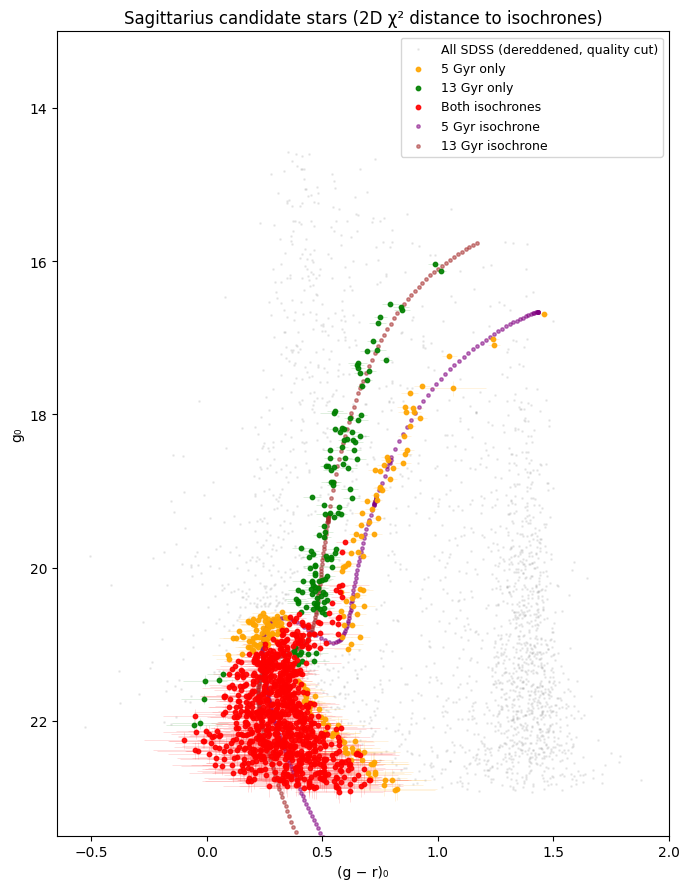

In [10]:
# Color uncertainty (quadrature)
d["sig_gr"] = np.sqrt(d["psfMagErr_g"]**2 + d["psfMagErr_r"]**2)

# Build isochrone point clouds in (g0, (g-r)0) space
def iso_points(iso, DM):
    iso_df = iso.df
    g_app = iso_df["sdss_g"].to_numpy() + DM
    r_app = iso_df["sdss_r"].to_numpy() + DM
    c_app = g_app - r_app
    return g_app, c_app

g5_iso, c5_iso   = iso_points(iso5, DM)
g13_iso, c13_iso = iso_points(iso13, DM)

# -----------------------------
# FIXED candidate metric: 2D chi^2 distance to isochrone
# -----------------------------
CHI2_THRESH = 6.18      # ~95% region for 2 dof (tunable)
DG_WINDOW   = 0.50      # only compare to iso points within +/- this many mag in g

# Star arrays
star_g    = d["g0"].to_numpy()
star_c    = d["g_r"].to_numpy()
sigma_g   = d["psfMagErr_g"].to_numpy()
sigma_c   = d["sig_gr"].to_numpy()

# Prevent divide-by-zero (shouldn't happen, but safe)
sigma_g = np.maximum(sigma_g, 1e-6)
sigma_c = np.maximum(sigma_c, 1e-6)

def min_chi2_to_iso(star_g, star_c, sigma_g, sigma_c, iso_g, iso_c, dg_window=0.5, nbins=200):
    """
    Compute minimum chi^2 distance from each star to an isochrone in (g, color) space:
        chi^2 = ((g - g_iso)/sigma_g)^2 + ((c - c_iso)/sigma_c)^2
    Only compare stars to isochrone points within +/- dg_window in g to avoid silly matches.
    Returns: min_chi2 array (len = number of stars).
    """
    # Bin the isochrone points by g to speed up lookup
    gmin, gmax = np.nanmin(iso_g), np.nanmax(iso_g)
    edges = np.linspace(gmin, gmax, nbins + 1)
    bin_id = np.clip(np.digitize(iso_g, edges) - 1, 0, nbins - 1)

    # Store indices for each bin
    bins = [[] for _ in range(nbins)]
    for i, b in enumerate(bin_id):
        bins[b].append(i)

    # For each star, compare only to bins around its g
    min_chi2 = np.full_like(star_g, np.inf, dtype=float)

    # precompute star bin ids
    star_bin = np.clip(np.digitize(star_g, edges) - 1, 0, nbins - 1)

    # How many bins correspond to dg_window?
    dg_per_bin = (gmax - gmin) / nbins
    half_bins = max(1, int(np.ceil(dg_window / dg_per_bin)))

    for j in range(len(star_g)):
        b0 = max(0, star_bin[j] - half_bins)
        b1 = min(nbins - 1, star_bin[j] + half_bins)

        # Gather candidate iso indices
        cand_idx = []
        for b in range(b0, b1 + 1):
            cand_idx.extend(bins[b])

        if not cand_idx:
            continue

        gi = iso_g[cand_idx]
        ci = iso_c[cand_idx]

        # Also enforce absolute dg window (hard cut)
        dg = star_g[j] - gi
        keep = np.abs(dg) <= dg_window
        if not np.any(keep):
            continue

        gi = gi[keep]
        ci = ci[keep]
        dg = dg[keep]
        dc = star_c[j] - ci

        chi2 = (dg / sigma_g[j])**2 + (dc / sigma_c[j])**2
        min_chi2[j] = np.min(chi2)

    return min_chi2

# Compute min chi^2 for each star to each isochrone
chi2_5  = min_chi2_to_iso(star_g, star_c, sigma_g, sigma_c, g5_iso,  c5_iso,  dg_window=DG_WINDOW)
chi2_13 = min_chi2_to_iso(star_g, star_c, sigma_g, sigma_c, g13_iso, c13_iso, dg_window=DG_WINDOW)

# Candidate flags
is5   = np.isfinite(chi2_5)  & (chi2_5  < CHI2_THRESH)
is13  = np.isfinite(chi2_13) & (chi2_13 < CHI2_THRESH)
isboth = is5 & is13
is5only = is5 & ~is13
is13only = is13 & ~is5

print(f"Total stars after quality cut: {len(d)}")
print(f"Candidates (5 Gyr only):  {is5only.sum()}")
print(f"Candidates (13 Gyr only): {is13only.sum()}")
print(f"Candidates (both):         {isboth.sum()}")
print(f"Candidates (either):       {(is5 | is13).sum()}")
print(f"(chi2 threshold={CHI2_THRESH}, dg_window=±{DG_WINDOW} mag)")

# -----------------------------
# Plot with faint error bars
# -----------------------------
plt.figure(figsize=(7, 9))

# Background
plt.scatter(d["g_r"], d["g0"], s=1, alpha=0.12, color="gray",
            label="All SDSS (dereddened, quality cut)")

def plot_with_errors(mask, color, label):
    x = star_c[mask]
    y = star_g[mask]
    xerr = sigma_c[mask]
    yerr = sigma_g[mask]

    plt.scatter(x, y, s=10, color=color, alpha=0.9, label=label, zorder=3)
    plt.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor=color,
        alpha=0.15,
        elinewidth=0.6,
        capsize=0,
        zorder=2
    )

plot_with_errors(is5only,  "orange", "5 Gyr only")
plot_with_errors(is13only, "green",  "13 Gyr only")
plot_with_errors(isboth,   "red",    "Both isochrones")

# Isochrones as points (no zig-zag lines)
plt.scatter(c5_iso,  g5_iso,  s=6, alpha=0.5, color="purple", label="5 Gyr isochrone")
plt.scatter(c13_iso, g13_iso, s=6, alpha=0.5, color="brown",  label="13 Gyr isochrone")

plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title("Sagittarius candidate stars (2D χ² distance to isochrones)")
plt.ylim(23.5, 13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

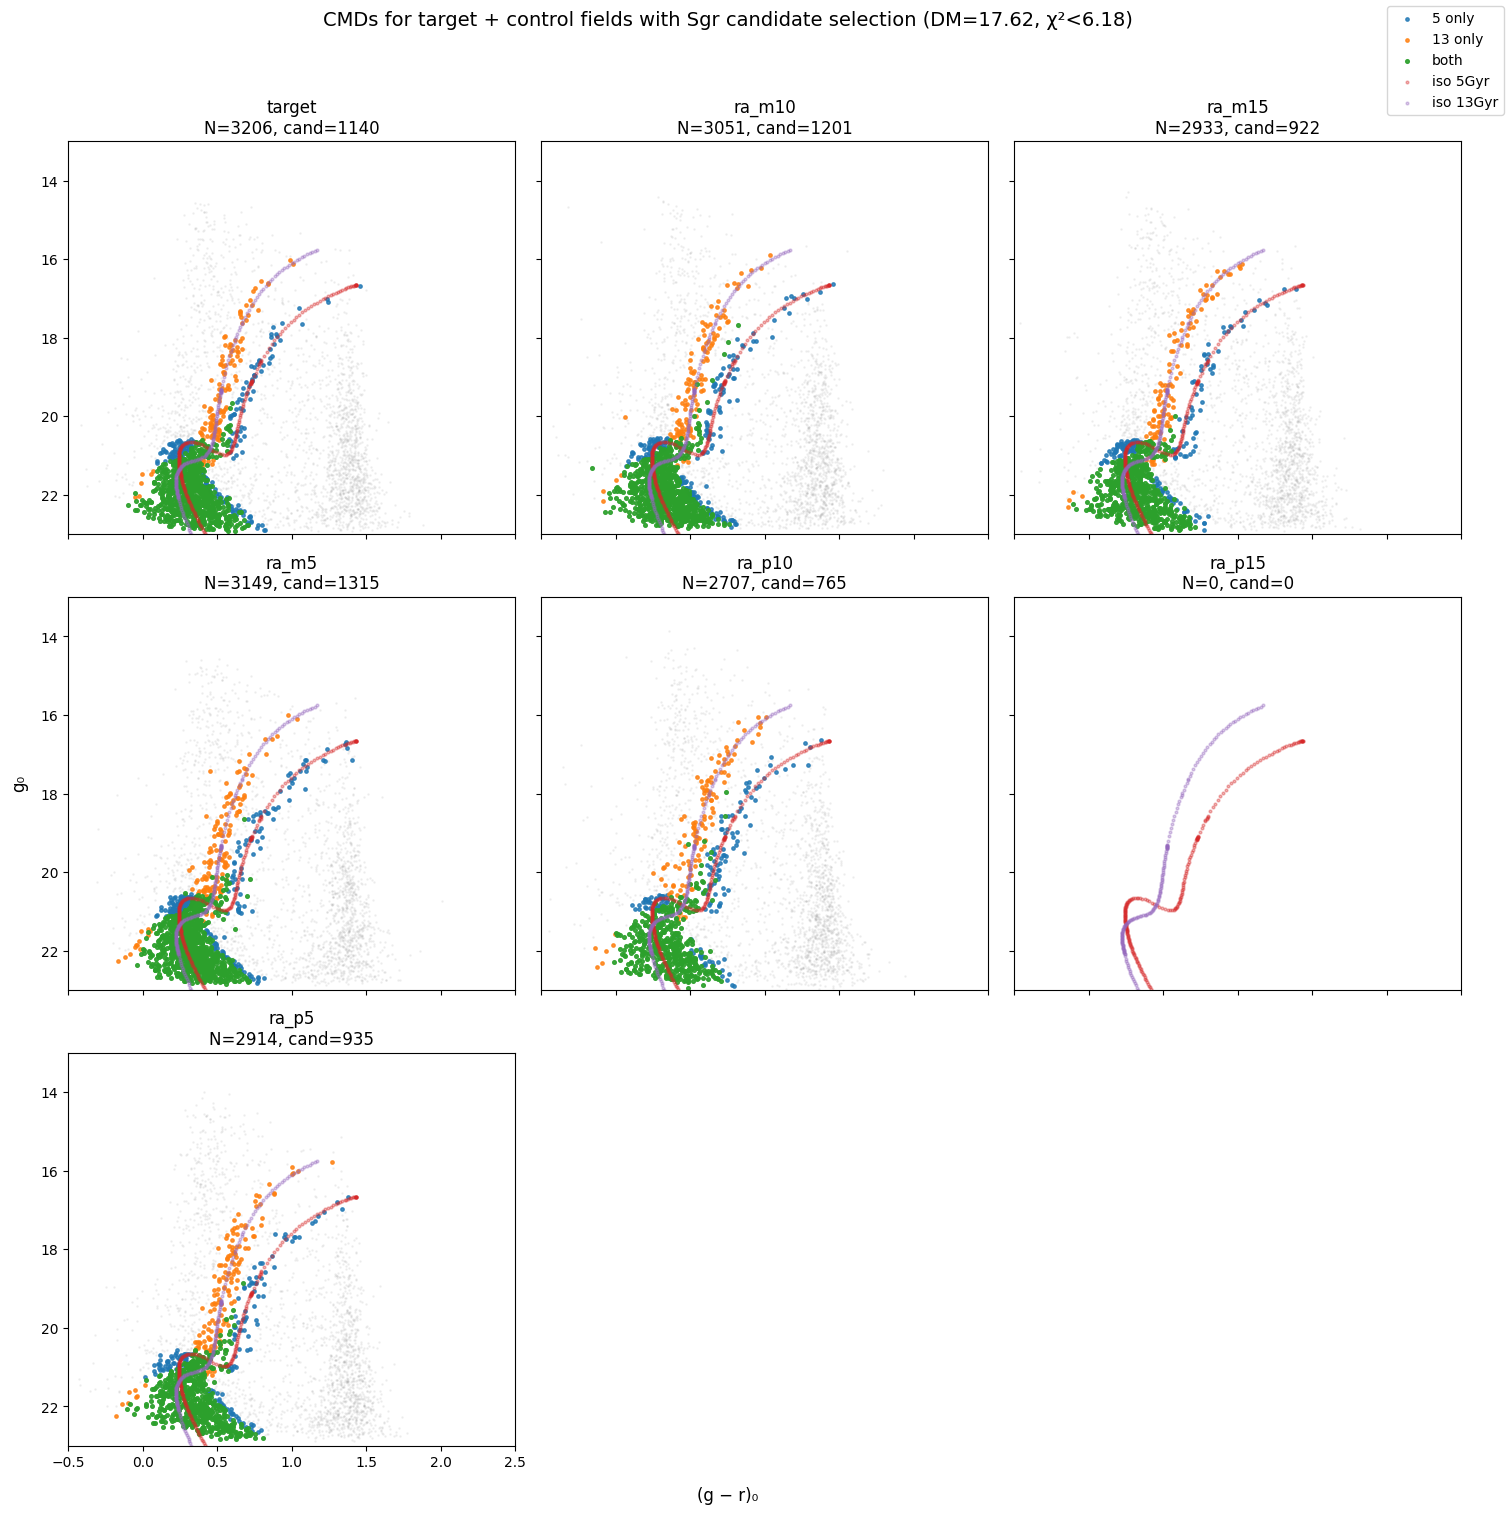

In [ ]:
# -----------------------------
# CONFIG (keep consistent!)
# -----------------------------
FIELDS_DIR = "sdss_data/fields"
PATTERN = os.path.join(FIELDS_DIR, "sdss_*.csv")

ERR_MAX = 0.15
G0_MAX = 23.5
R0_MAX = 23.5

d_pc = 33_400.0
DM = 5.0 * np.log10(d_pc / 10.0)

CHI2_THRESH = 6.18   # ~95% for 2 dof (tunable)
DG_WINDOW = 0.50     # +/- mag window to compare to isochrone points
NBINS = 200          # speed/accuracy tradeoff for binning iso points

# -----------------------------
# Isochrone point clouds
# -----------------------------
def iso_points(iso, DM):
    iso_df = iso.df
    g_app = iso_df["sdss_g"].to_numpy() + DM
    r_app = iso_df["sdss_r"].to_numpy() + DM
    c_app = g_app - r_app
    return g_app, c_app

g5_iso, c5_iso   = iso_points(iso5, DM)
g13_iso, c13_iso = iso_points(iso13, DM)

def min_chi2_to_iso(star_g, star_c, sigma_g, sigma_c, iso_g, iso_c, dg_window=0.5, nbins=200):
    gmin, gmax = np.nanmin(iso_g), np.nanmax(iso_g)
    edges = np.linspace(gmin, gmax, nbins + 1)
    bin_id = np.clip(np.digitize(iso_g, edges) - 1, 0, nbins - 1)

    bins = [[] for _ in range(nbins)]
    for i, b in enumerate(bin_id):
        bins[b].append(i)

    star_bin = np.clip(np.digitize(star_g, edges) - 1, 0, nbins - 1)
    dg_per_bin = (gmax - gmin) / nbins
    half_bins = max(1, int(np.ceil(dg_window / dg_per_bin)))

    min_chi2 = np.full_like(star_g, np.inf, dtype=float)

    for j in range(len(star_g)):
        b0 = max(0, star_bin[j] - half_bins)
        b1 = min(nbins - 1, star_bin[j] + half_bins)

        cand_idx = []
        for b in range(b0, b1 + 1):
            cand_idx.extend(bins[b])
        if not cand_idx:
            continue

        gi = iso_g[cand_idx]
        ci = iso_c[cand_idx]

        dg = star_g[j] - gi
        keep = np.abs(dg) <= dg_window
        if not np.any(keep):
            continue

        gi = gi[keep]
        ci = ci[keep]
        dg = dg[keep]
        dc = star_c[j] - ci

        chi2 = (dg / sigma_g[j])**2 + (dc / sigma_c[j])**2
        min_chi2[j] = np.min(chi2)

    return min_chi2

def load_field_csv(path):
    # SDSS CSVs often begin with "#Table1" comment line
    df0 = pd.read_csv(path, comment="#")

    # Deredden (if your loader already does this, it's still safe to recompute)
    df0["g0"] = df0["psfMag_g"] - df0["extinction_g"]
    df0["r0"] = df0["psfMag_r"] - df0["extinction_r"]
    df0["g_r"] = df0["g0"] - df0["r0"]

    # Color uncertainty
    df0["sig_gr"] = np.sqrt(df0["psfMagErr_g"]**2 + df0["psfMagErr_r"]**2)

    # Quality mask (same as target)
    m = (
        (df0["psfMagErr_g"] < ERR_MAX) &
        (df0["psfMagErr_r"] < ERR_MAX) &
        (df0["g0"] < G0_MAX) &
        (df0["r0"] < R0_MAX)
    )
    return df0[m].copy()

def classify_candidates(df_field):
    star_g  = df_field["g0"].to_numpy()
    star_c  = df_field["g_r"].to_numpy()
    sig_g   = np.maximum(df_field["psfMagErr_g"].to_numpy(), 1e-6)
    sig_c   = np.maximum(df_field["sig_gr"].to_numpy(), 1e-6)

    chi2_5  = min_chi2_to_iso(star_g, star_c, sig_g, sig_c, g5_iso,  c5_iso,  dg_window=DG_WINDOW, nbins=NBINS)
    chi2_13 = min_chi2_to_iso(star_g, star_c, sig_g, sig_c, g13_iso, c13_iso, dg_window=DG_WINDOW, nbins=NBINS)

    is5  = np.isfinite(chi2_5)  & (chi2_5  < CHI2_THRESH)
    is13 = np.isfinite(chi2_13) & (chi2_13 < CHI2_THRESH)

    isboth  = is5 & is13
    is5only = is5 & ~is13
    is13only = is13 & ~is5
    iseither = is5 | is13

    out = df_field.copy()
    out["cand_5only"] = is5only
    out["cand_13only"] = is13only
    out["cand_both"] = isboth
    out["cand_either"] = iseither
    out["chi2_5"] = chi2_5
    out["chi2_13"] = chi2_13
    return out

# -----------------------------
# Load and classify all fields
# -----------------------------
paths = sorted(glob.glob(PATTERN))
if not paths:
    raise FileNotFoundError(f"No files matched {PATTERN}")

fields = []
for p in paths:
    field_id = os.path.basename(p).replace("sdss_", "").replace(".csv", "")
    df_field = load_field_csv(p)
    df_field = classify_candidates(df_field)
    fields.append((field_id, df_field))

# keep target + 8 random controls for plotting
random.seed(0)
target = [t for t in fields if t[0] == "target"]
controls_list = [t for t in fields if t[0] != "target"]
plot_fields = target + random.sample(controls_list, k=min(8, len(controls_list)))

fields_for_plot = plot_fields

# -----------------------------
# Plot subplots
# -----------------------------
n = len(plot_fields)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 5.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, (fid, df_field) in zip(axes, plot_fields):
    # background
    ax.scatter(df_field["g_r"], df_field["g0"], s=1, alpha=0.08, color="gray")

    # candidates
    ax.scatter(df_field.loc[df_field["cand_5only"], "g_r"],
               df_field.loc[df_field["cand_5only"], "g0"],
               s=6, alpha=0.8, label="5 only")
    ax.scatter(df_field.loc[df_field["cand_13only"], "g_r"],
               df_field.loc[df_field["cand_13only"], "g0"],
               s=6, alpha=0.8, label="13 only")
    ax.scatter(df_field.loc[df_field["cand_both"], "g_r"],
               df_field.loc[df_field["cand_both"], "g0"],
               s=7, alpha=0.9, label="both")

    # isochrones (points)
    ax.scatter(c5_iso, g5_iso, s=4, alpha=0.35, label="iso 5Gyr")
    ax.scatter(c13_iso, g13_iso, s=4, alpha=0.35, label="iso 13Gyr")

    ax.set_title(f"{fid}\nN={len(df_field)}, cand={int(df_field['cand_either'].sum())}")

    ax.invert_yaxis()
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(23, 13)

# Hide unused axes
for k in range(len(fields), len(axes)):
    axes[k].axis("off")

# Shared labels
fig.text(0.5, 0.04, "(g − r)₀", ha="center", fontsize=12)
fig.text(0.04, 0.5, "g₀", va="center", rotation="vertical", fontsize=12)
fig.suptitle(f"CMDs for target + control fields with Sgr candidate selection (DM={DM:.2f}, χ²<{CHI2_THRESH})",
             y=0.995, fontsize=14)

# One legend (avoid duplicates)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:5], labels[:5], loc="upper right", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.97])
plt.show()

,field,N,N_cand,f_cand
1,ra_m10,3051,1201,0.393641
2,ra_m15,2933,922,0.314354
3,ra_m5,3149,1315,0.417593
4,ra_p10,2707,765,0.282601
5,ra_p15,0,0,NaN
6,ra_p5,2914,935,0.320865
0,target,3206,1140,0.355583


=== Overdensity statistic (candidate fraction) ===
Target:    N=3206, N_cand=1140, f=0.35558
Controls:  mean f=0.34581, std f=0.05711  (n=6)
Excess:    Δf=0.00977
Significance (using control scatter): S = 0.17 σ


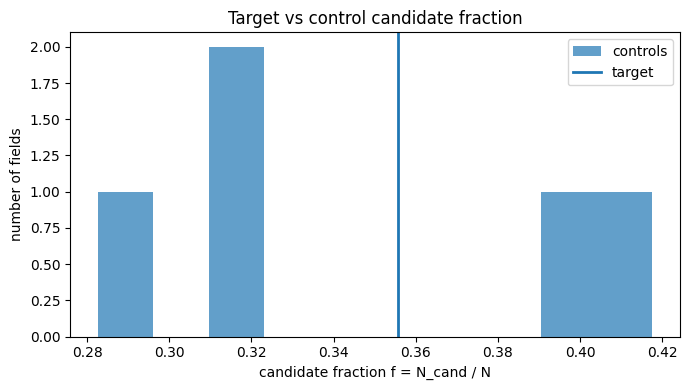

In [ ]:
rows = []
for fid, df_field in fields:
    N = len(df_field)
    Nc = int(df_field["cand_either"].sum())
    f = Nc / N if N > 0 else np.nan
    rows.append({"field": fid, "N": N, "N_cand": Nc, "f_cand": f})

summary = pd.DataFrame(rows).sort_values("field")
display(summary)

target_f = summary.loc[summary["field"] == "target", "f_cand"].iloc[0]
target_N = summary.loc[summary["field"] == "target", "N"].iloc[0]
target_Nc = summary.loc[summary["field"] == "target", "N_cand"].iloc[0]

controls = summary[summary["field"] != "target"].copy()
mu = controls["f_cand"].mean()
sigma = controls["f_cand"].std(ddof=1)

# "Sigma" significance based on field-to-field variance
S = (target_f - mu) / sigma if sigma > 0 else np.nan

print("=== Overdensity statistic (candidate fraction) ===")
print(f"Target:    N={target_N}, N_cand={target_Nc}, f={target_f:.5f}")
print(f"Controls:  mean f={mu:.5f}, std f={sigma:.5f}  (n={len(controls)})")
print(f"Excess:    Δf={target_f-mu:.5f}")
print(f"Significance (using control scatter): S = {S:.2f} σ")

# Optional: show target vs control distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.hist(controls["f_cand"], bins=10, alpha=0.7, label="controls")
plt.axvline(target_f, linewidth=2, label="target")
plt.xlabel("candidate fraction f = N_cand / N")
plt.ylabel("number of fields")
plt.title("Target vs control candidate fraction")
plt.legend()
plt.tight_layout()
plt.show()